# Protein sequence alignment — HC, CC & AA (Aedes aegypti) receptor datasets

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from Bio import Align
from Bio.Align import substitution_matrices
from Bio.Seq import Seq
from Bio.SeqRecord import SeqRecord
from Bio import SeqIO

DATA_DIR = "../data"
RESULTS_DIR = "../results"
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(DATA_DIR, exist_ok=True)

# Each dataset: CSV path + the column naming the receptor. All share a 'Protein sequence' column.
DATASETS = {
    "HC": {
        "csv": "/projectnb/biochemai/Grant/lorax_brian/data/HC/raw/all_dat_z_score.csv",
        "id_col": "Protein",
        "seq_col": "Protein sequence",
    },
    "CC": {
        # CC_just_seqs.csv is already deduplicated to the 50 unique receptors
        "csv": "/projectnb/biochemai/Grant/lorax_brian/data/CC/raw/CC_just_seqs.csv",
        "id_col": "RECEPTOR",
        "seq_col": "Protein sequence",
    },
    # NEW: Aedes aegypti ORs, parsed from AaegORs.docx by src/parse_aaeg_docx.py.
    # 114 receptors incl. 7 pseudogenes (see the 'status' column in the CSV).
    "AA": {
        "csv": "/projectnb/biochemai/Grant/lorax_brian/data/AA/raw/AaegORs.csv",
        "id_col": "RECEPTOR",
        "seq_col": "Protein sequence",
    },
}

## Helpers

Global (Needleman-Wunsch) alignment with BLOSUM62 and affine gap penalties. Similarity convention
follows EMBOSS `needle`: a column counts as **similar** if residues are identical *or* a
conservative substitution (positive BLOSUM62 score), divided by the full alignment length
(gaps included). Identity is computed alongside for reference.

In [2]:
blosum62 = substitution_matrices.load("BLOSUM62")

aligner = Align.PairwiseAligner()
aligner.substitution_matrix = blosum62
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5
aligner.mode = "global"


def extract_sequences(cfg):
    """Load CSV, dedupe to unique receptors, return (names, seqs) and write a FASTA."""
    df = pd.read_csv(cfg["csv"])
    uniq = df.drop_duplicates(subset=cfg["id_col"])[[cfg["id_col"], cfg["seq_col"]]].reset_index(drop=True)
    names = uniq[cfg["id_col"]].astype(str).tolist()
    seqs = uniq[cfg["seq_col"]].tolist()
    return names, seqs


def score_alignment(alignment, matrix):
    """Return (% identity, % similarity) over the aligned columns.
    identity: exact residue match. similarity: identical OR positive BLOSUM62 score."""
    a, b = alignment[0], alignment[1]
    ident = sim = 0
    for x, y in zip(a, b):
        if x == "-" or y == "-":
            continue
        if x == y:
            ident += 1
            sim += 1
        elif matrix[x, y] > 0:
            sim += 1
    L = len(a)
    return 100.0 * ident / L, 100.0 * sim / L


def all_vs_all(seqs):
    """Return (identity_matrix, similarity_matrix) over all pairs."""
    n = len(seqs)
    pid = np.zeros((n, n))
    psim = np.zeros((n, n))
    for i in range(n):
        pid[i, i] = psim[i, i] = 100.0
        for j in range(i + 1, n):
            aln = aligner.align(seqs[i], seqs[j])[0]
            ident, sim = score_alignment(aln, blosum62)
            pid[i, j] = pid[j, i] = ident
            psim[i, j] = psim[j, i] = sim
    return pid, psim


def plot_heatmap(psim, names, title, out_png):
    """Cluster by similarity and draw a heatmap with the diagonal masked."""
    from scipy.cluster.hierarchy import linkage, dendrogram
    from scipy.spatial.distance import squareform

    n = len(names)
    off = psim[np.triu_indices(n, k=1)]
    dist = 100.0 - psim
    np.fill_diagonal(dist, 0.0)
    Z = linkage(squareform(dist, checks=False), method="average")
    order = dendrogram(Z, no_plot=True)["leaves"]

    sim_ord = psim[np.ix_(order, order)].copy()
    np.fill_diagonal(sim_ord, np.nan)  # blank self-comparisons so they don't dominate the scale
    names_ord = [names[i] for i in order]

    cmap = plt.get_cmap("viridis").copy()
    cmap.set_bad("lightgrey")
    fs = 7 if n <= 30 else 5
    fig, ax = plt.subplots(figsize=(10, 8) if n <= 30 else (13, 11))
    im = ax.imshow(sim_ord, cmap=cmap, vmin=off.min(), vmax=off.max())
    ax.set_xticks(range(n)); ax.set_xticklabels(names_ord, rotation=90, fontsize=fs)
    ax.set_yticks(range(n)); ax.set_yticklabels(names_ord, fontsize=fs)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="% similarity")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.show()

## 1. Extract sequences + write FASTA (both datasets)

In [3]:
data = {}
for name, cfg in DATASETS.items():
    names, seqs = extract_sequences(cfg)
    fasta = os.path.join(DATA_DIR, f"{name}_receptors.fasta")
    SeqIO.write(
        [SeqRecord(Seq(s), id=nm, description="") for nm, s in zip(names, seqs)],
        fasta, "fasta",
    )
    lengths = np.array([len(s) for s in seqs])
    data[name] = {"names": names, "seqs": seqs}
    print(f"{name}: {len(seqs)} unique receptors | length min={lengths.min()} "
          f"mean={lengths.mean():.0f} max={lengths.max()} -> {fasta}")

HC: 24 unique receptors | length min=375 mean=396 max=417 -> ../data/HC_receptors.fasta
CC: 50 unique receptors | length min=367 mean=396 max=432 -> ../data/CC_receptors.fasta
AA: 114 unique receptors | length min=337 mean=402 max=478 -> ../data/AA_receptors.fasta


## 2. All-vs-all similarity matrices

HC = 276 pairs, CC = 1225 pairs. A minute or so total.

In [4]:
for name in data:
    seqs, names = data[name]["seqs"], data[name]["names"]
    pid, psim = all_vs_all(seqs)
    data[name]["pid"] = pid
    data[name]["psim"] = psim
    n = len(seqs)
    off_id = pid[np.triu_indices(n, k=1)]
    off_sim = psim[np.triu_indices(n, k=1)]
    print(f"=== {name} ({n} receptors, {len(off_sim)} pairs) ===")
    print(f"  % identity:   min={off_id.min():.1f} mean={off_id.mean():.1f} max={off_id.max():.1f}")
    print(f"  % similarity: min={off_sim.min():.1f} mean={off_sim.mean():.1f} max={off_sim.max():.1f}")

=== HC (24 receptors, 276 pairs) ===
  % identity:   min=15.2 mean=20.5 max=42.2
  % similarity: min=28.3 mean=38.3 max=62.5
=== CC (50 receptors, 1225 pairs) ===
  % identity:   min=13.5 mean=21.2 max=96.4
  % similarity: min=26.8 mean=38.6 max=98.1
=== AA (114 receptors, 6441 pairs) ===
  % identity:   min=12.8 mean=20.1 max=99.7
  % similarity: min=23.5 mean=37.6 max=100.0


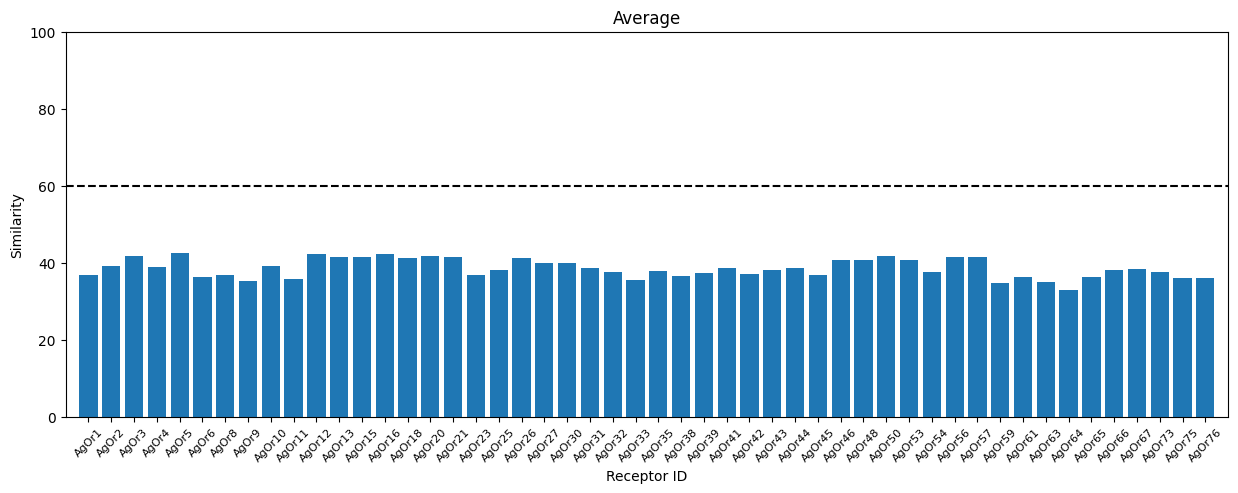

In [13]:

result = {}
for i in range(50):
    result[data['CC']['names'][i]] = np.delete(data['CC']['psim'][i], i).mean()
plt.figure(figsize=(15, 5))
plt.bar(result.keys(), result.values())
#plt.hist(data['CC']['psim'][0])
plt.title('Average')
plt.ylim(0, 100)
plt.xlim(-1, 50)
plt.xticks(fontsize=8, rotation=45)
plt.axhline(60, color='k', linestyle='--')
plt.xlabel('Receptor ID')
plt.ylabel('Similarity')
plt.show()

[47.77777777777778, 51.37844611528822, 46.25850340136054, 81.5909090909091, 73.42105263157895, 43.619489559164734, 83.16582914572864, 90.18087855297158, 90.18087855297158, 60.80402010050251, 81.90954773869346, 81.90954773869346, 71.35416666666667, 79.16666666666667, 79.16666666666667, 55.31400966183575, 55.31400966183575, 83.16582914572864, 96.5, 96.5, 98.05352798053528]


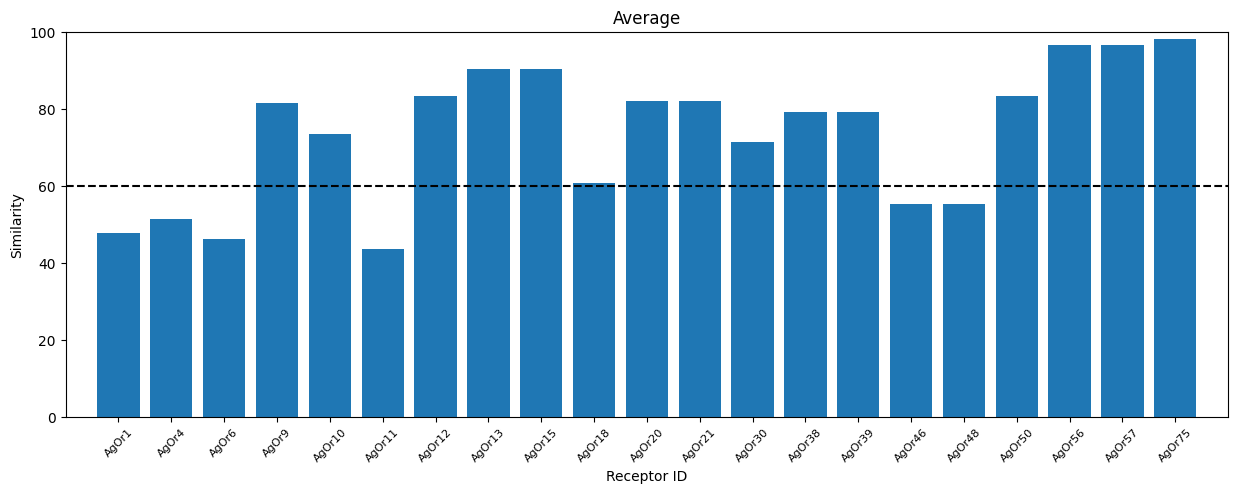

In [9]:
result = {}
for i in range(50):
    if data['CC']['names'][i][4:] in ['57', '21', '18', '12', '50', '20', '38', '46', '56', '30', '4', '15', '9', '39', '48', '11', '13', '75', '10', '6', '1']:
        result[data['CC']['names'][i]] = np.delete(data['CC']['psim'][i], i).max()
plt.figure(figsize=(15, 5))
plt.bar(result.keys(), result.values())
#plt.hist(data['CC']['psim'][0])
plt.title('Average')
plt.ylim(0, 100)
plt.xlim(-1, 21 )
plt.xticks(fontsize=8, rotation=45)
plt.axhline(60, color='k', linestyle='--')
plt.xlabel('Receptor ID')
plt.ylabel('Similarity')
print([float(v) for v in result.values()])
plt.show()


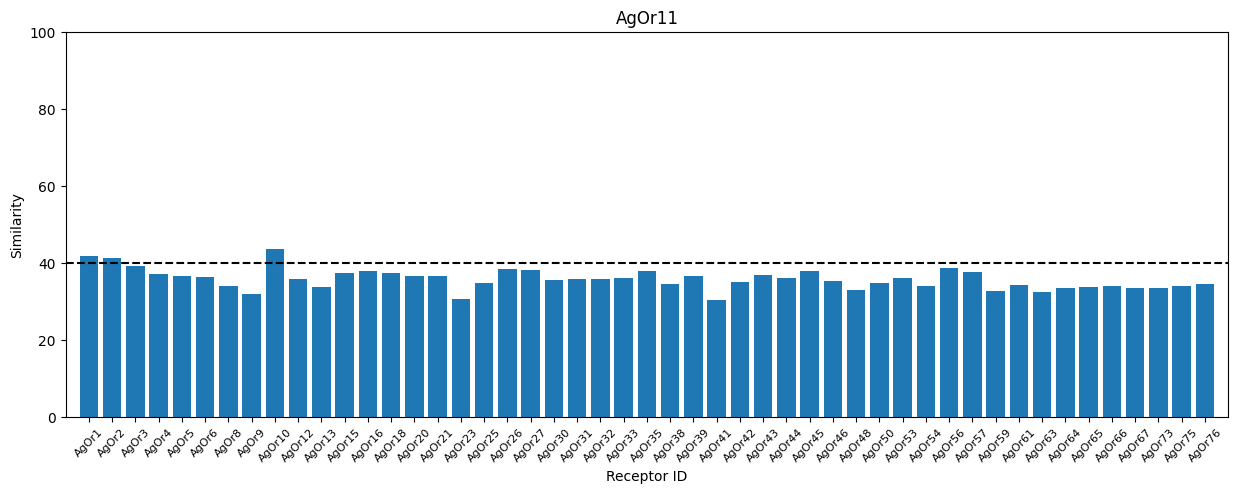

In [10]:
receptor = 'AgOr11'
ind = data['CC']['names'].index(receptor)
#ind = 10
plt.figure(figsize=(15, 5))
plt.bar(np.arange(49), np.delete(data['CC']['psim'][ind], ind))
#plt.hist(data['CC']['psim'][0])
plt.title(receptor)
plt.ylim(0, 100)
plt.xlim(-1, 49)
plt.xticks(np.arange(49), np.delete(data['CC']['names'], ind), fontsize=8, rotation=45)
plt.axhline(40, color='k', linestyle='--')
plt.xlabel('Receptor ID')
plt.ylabel('Similarity')
plt.show()

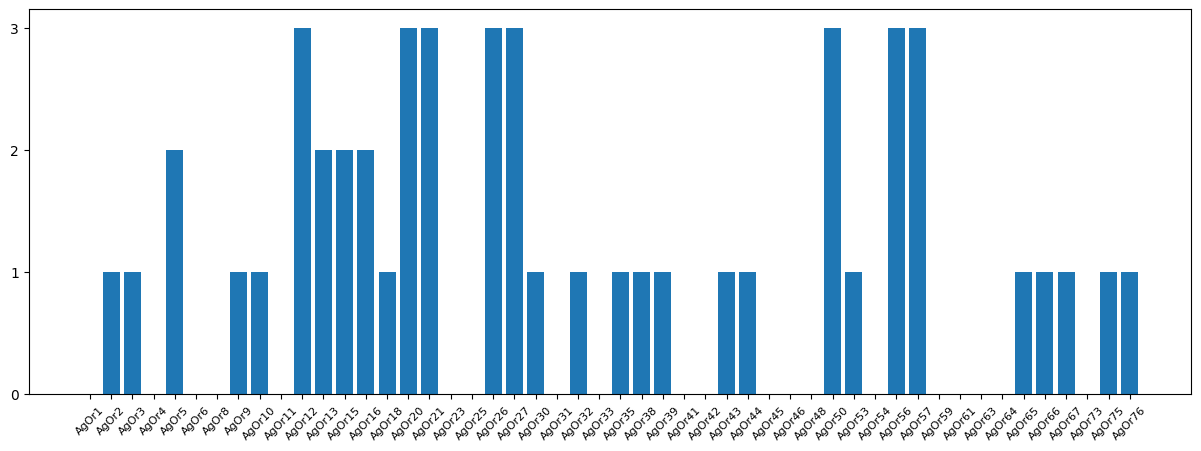

In [63]:
result = {}
for i in np.arange(50):
    result[data['CC']['names'][i]] = int((data['CC']['psim'][i] > 60).sum() -1)
plt.figure(figsize=(15, 5))
plt.bar(result.keys(), result.values())
plt.xticks(fontsize=8, rotation=45)
plt.yticks(np.arange(4), np.arange(4))
plt.show()

## 3. Clustered similarity heatmaps (diagonal masked)

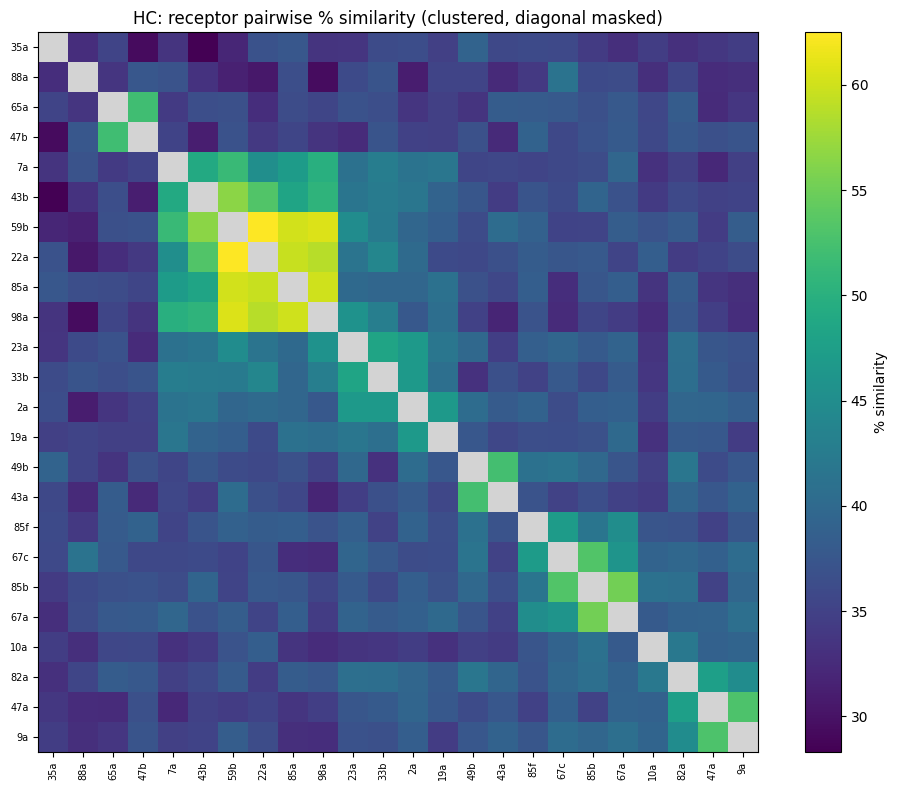

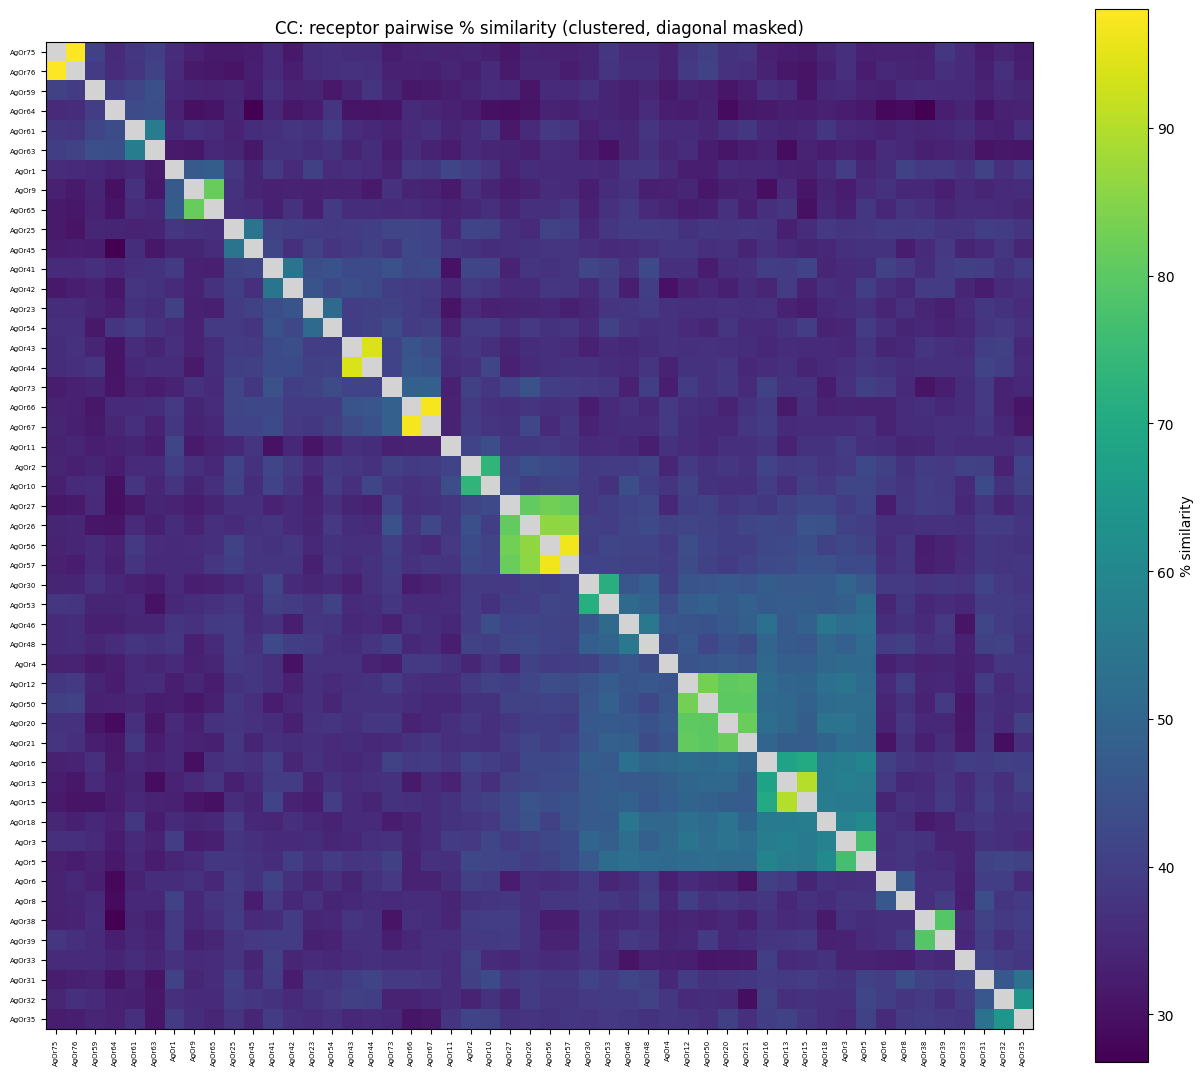

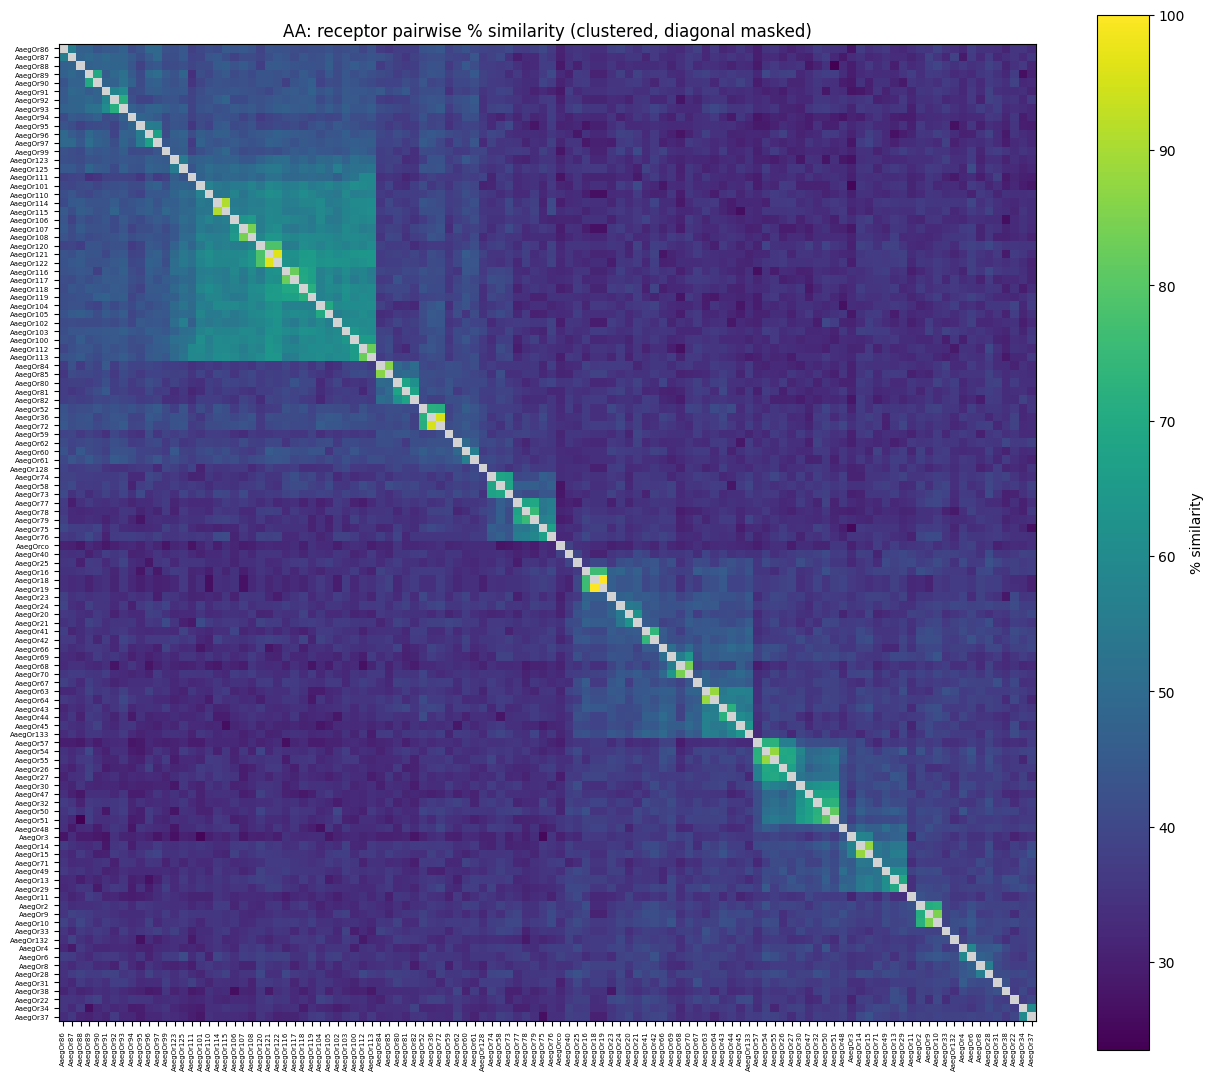

In [5]:
for name in data:
    plot_heatmap(
        data[name]["psim"], data[name]["names"],
        title=f"{name}: receptor pairwise % similarity (clustered, diagonal masked)",
        out_png=f"../results/{name}_similarity_heatmap.png",
    )

## 3b. Cross-dataset comparison: HC vs CC

Align every HC receptor against every CC receptor (24 x 50 = 1200 pairs) to ask how similar
the *Drosophila* (HC) and *Anopheles* (CC) odorant receptors are to each other. Same global
alignment + EMBOSS-style % similarity. The matrix is rectangular (rows = HC, cols = CC), so the
diagonal is not meaningful and nothing is masked.

In [6]:
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import pdist

hc_names, hc_seqs = data["HC"]["names"], data["HC"]["seqs"]
cc_names, cc_seqs = data["CC"]["names"], data["CC"]["seqs"]

# 24 x 50 cross similarity matrix
cross = np.zeros((len(hc_seqs), len(cc_seqs)))
for i, hs in enumerate(hc_seqs):
    for j, cs in enumerate(cc_seqs):
        aln = aligner.align(hs, cs)[0]
        _, sim = score_alignment(aln, blosum62)
        cross[i, j] = sim

cross_df = pd.DataFrame(cross, index=hc_names, columns=cc_names)
cross_df.round(1).to_csv("../results/HC_vs_CC_similarity_matrix.csv")
print(f"HC vs CC: {cross.size} cross pairs")
print(f"  % similarity: min={cross.min():.1f} mean={cross.mean():.1f} max={cross.max():.1f}")
print("  (within-HC mean=38.3, within-CC mean=38.6 for reference)\n")

# best cross match for each HC receptor
print("Best CC match per HC receptor:")
for i, nm in enumerate(hc_names):
    j = int(np.argmax(cross[i]))
    print(f"  {nm:>6s} -> {cc_names[j]:<8s} {cross[i, j]:.1f}%")

HC vs CC: 1200 cross pairs
  % similarity: min=28.1 mean=36.4 max=60.5
  (within-HC mean=38.3, within-CC mean=38.6 for reference)

Best CC match per HC receptor:
     65a -> AgOr31   42.3%
     43b -> AgOr53   39.6%
     23a -> AgOr31   43.4%
     59b -> AgOr30   39.4%
     47a -> AgOr31   44.0%
      7a -> AgOr8    40.9%
     85a -> AgOr25   40.3%
     85b -> AgOr8    50.0%
     98a -> AgOr46   39.9%
      2a -> AgOr48   42.8%
     67a -> AgOr8    47.3%
     88a -> AgOr5    38.3%
      9a -> AgOr31   45.6%
     82a -> AgOr31   48.6%
     10a -> AgOr39   46.9%
     33b -> AgOr4    40.8%
     47b -> AgOr26   41.3%
     85f -> AgOr31   43.2%
     49b -> AgOr10   60.5%
     67c -> AgOr8    47.4%
     35a -> AgOr25   42.3%
     43a -> AgOr10   56.9%
     19a -> AgOr25   43.0%
     22a -> AgOr2    40.0%


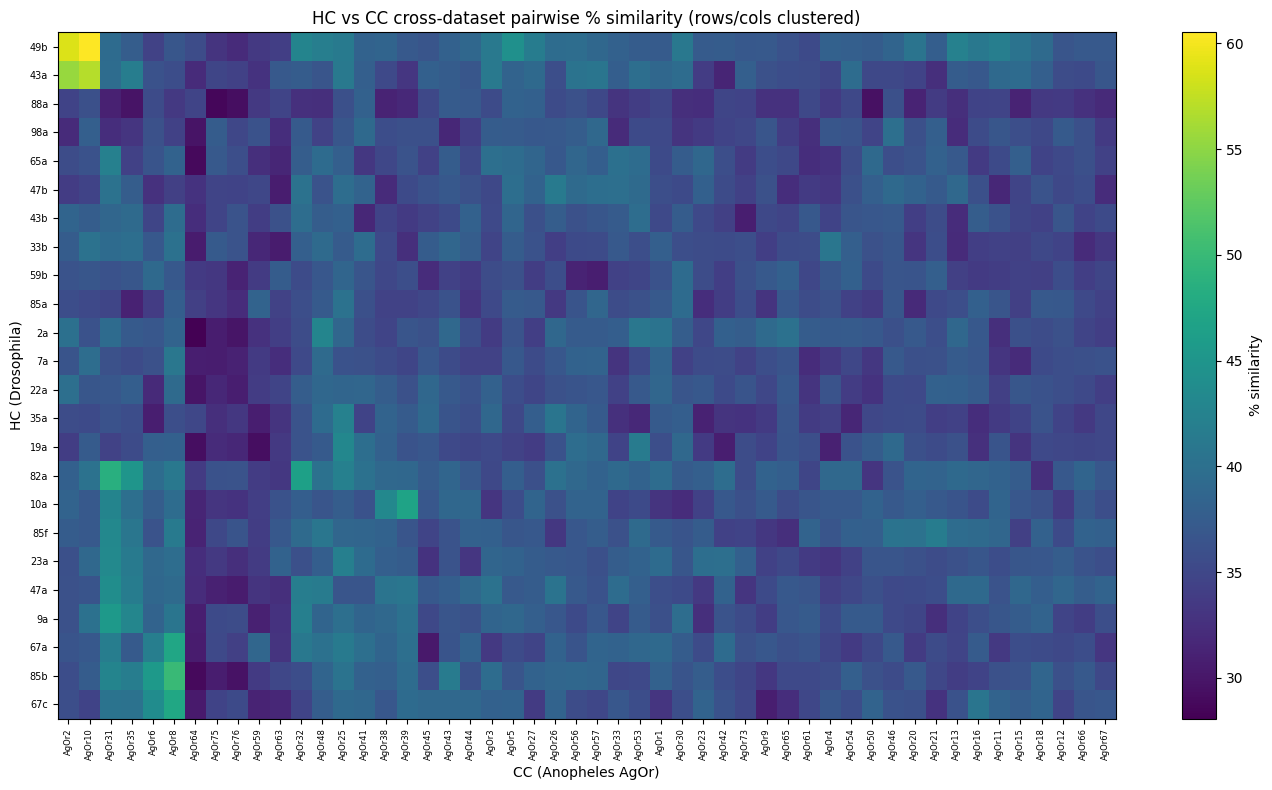

In [7]:
# cluster rows (HC) and cols (CC) independently for a readable block structure
row_order = leaves_list(linkage(pdist(cross), method="average"))
col_order = leaves_list(linkage(pdist(cross.T), method="average"))

M = cross[np.ix_(row_order, col_order)]
rlabels = [hc_names[i] for i in row_order]
clabels = [cc_names[j] for j in col_order]

fig, ax = plt.subplots(figsize=(14, 8))
im = ax.imshow(M, cmap="viridis", vmin=cross.min(), vmax=cross.max(), aspect="auto")
ax.set_xticks(range(len(clabels))); ax.set_xticklabels(clabels, rotation=90, fontsize=6)
ax.set_yticks(range(len(rlabels))); ax.set_yticklabels(rlabels, fontsize=7)
ax.set_xlabel("CC (Anopheles AgOr)"); ax.set_ylabel("HC (Drosophila)")
ax.set_title("HC vs CC cross-dataset pairwise % similarity (rows/cols clustered)")
fig.colorbar(im, ax=ax, label="% similarity")
plt.tight_layout()
plt.savefig("../results/HC_vs_CC_similarity_heatmap.png", dpi=150)
plt.show()

## 4. Similarity matrices as tables (optional)

In [8]:
for name in data:
    df = pd.DataFrame(data[name]["psim"], index=data[name]["names"], columns=data[name]["names"])
    df.round(1).to_csv(f"../results/{name}_similarity_matrix.csv")
    print(f"wrote ../results/{name}_similarity_matrix.csv  ({df.shape[0]}x{df.shape[1]})")

# preview HC
pd.DataFrame(data["HC"]["psim"], index=data["HC"]["names"], columns=data["HC"]["names"]).round(1)

wrote ../results/HC_similarity_matrix.csv  (24x24)
wrote ../results/CC_similarity_matrix.csv  (50x50)
wrote ../results/AA_similarity_matrix.csv  (114x114)


,65a,43b,23a,59b,47a,7a,85a,85b,98a,2a,...,10a,33b,47b,85f,49b,67c,35a,43a,19a,22a
65a,100.0,36.5,36.9,36.7,32.6,34.1,36.2,36.7,35.4,33.6,...,35.6,36.6,52.0,38.1,33.4,37.9,35.3,38.3,34.8,32.8
43b,36.5,100.0,41.6,56.5,35.0,49.1,48.3,39.3,50.6,41.7,...,34.2,42.6,31.2,37.2,37.5,35.9,28.3,34.4,39.2,53.2
23a,36.9,41.6,100.0,44.9,37.5,41.1,40.0,38.0,45.8,46.6,...,33.4,48.2,32.6,38.7,39.8,39.4,33.6,34.6,41.8,41.4
59b,36.7,56.5,44.9,100.0,34.3,51.4,60.1,35.4,60.8,39.6,...,37.1,42.4,36.9,39.0,36.2,35.2,32.0,40.5,38.5,62.5
47a,32.6,35.0,37.5,34.3,100.0,32.3,33.5,35.1,34.7,39.5,...,39.0,38.0,36.6,35.0,36.1,38.8,33.9,37.6,37.7,35.1
7a,34.1,49.1,41.1,51.4,32.3,100.0,47.1,36.3,49.9,41.3,...,33.2,42.8,35.3,35.3,35.5,35.7,33.5,35.6,41.7,45.2
85a,36.2,48.3,40.0,60.1,33.5,47.1,100.0,37.4,60.0,39.6,...,33.5,39.7,35.4,38.5,36.8,32.8,37.6,35.6,41.1,59.6
85b,36.7,39.3,38.0,35.4,35.1,36.3,37.4,100.0,35.5,38.6,...,41.0,35.7,36.9,41.7,39.9,53.2,34.3,36.6,36.8,37.8
98a,35.4,50.6,45.8,60.8,34.7,49.9,60.0,35.5,100.0,37.7,...,32.7,43.0,33.5,37.0,35.0,32.6,33.5,31.8,40.7,58.8
2a,33.6,41.7,46.6,39.6,39.5,41.3,39.6,38.6,37.7,100.0,...,34.6,46.6,34.9,39.1,40.4,36.3,36.4,38.1,46.8,40.2


## 5. New dataset: Aedes aegypti (AA) cross-comparisons

`AA` is now folded into all the per-dataset steps above (FASTA, within-AA similarity
matrix + clustered heatmap, summary stats) automatically via the `DATASETS` loop.

Below we add the cross-dataset comparisons that place these *Aedes aegypti* receptors
relative to the existing **CC** (*Anopheles* AgOr) and **HC** (*Drosophila*) sets, using
the same BLOSUM62 global-alignment % similarity. Each produces a clustered cross-heatmap,
a `*_similarity_matrix.csv`, and the single best cross-species match per AA receptor.

Note: the 7 AA pseudogenes are included here; filter on `status != "pseudogene"` in the
CSV if you want functional-only comparisons.

=== AA vs CC: 5700 cross pairs ===
  % similarity: min=22.8 mean=36.3 max=85.4
  Top 12 closest AA->CC matches:
      AaegOr10 -> AgOr10   85.4%
       AaegOr2 -> AgOr2    84.1%
       AaegOr9 -> AgOr10   82.2%
       AaegOr8 -> AgOr8    78.1%
      AaegOr11 -> AgOr11   72.5%
      AaegOr66 -> AgOr66   70.5%
       AaegOr6 -> AgOr6    68.5%
      AaegOr31 -> AgOr31   68.1%
      AaegOr42 -> AgOr41   68.0%
      AaegOr23 -> AgOr23   65.9%
      AaegOr69 -> AgOr73   64.7%
      AaegOr41 -> AgOr41   64.1%


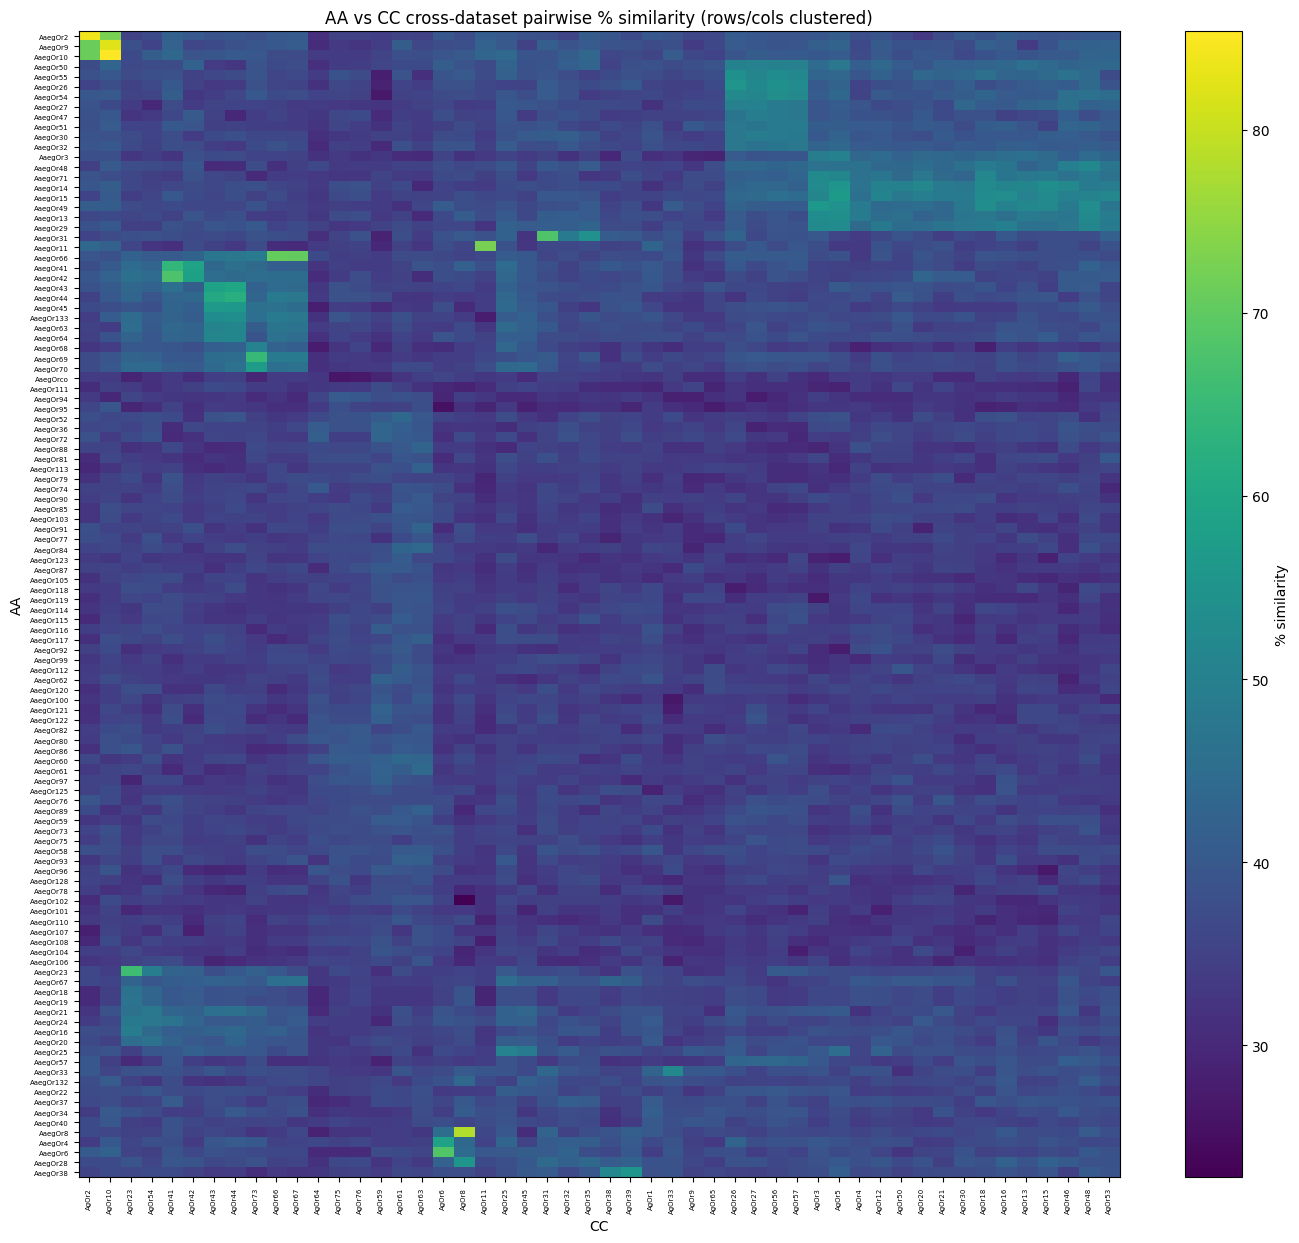

=== AA vs HC: 2736 cross pairs ===
  % similarity: min=25.7 mean=35.4 max=62.0
  Top 12 closest AA->HC matches:
       AaegOr2 -> 49b      62.0%
       AaegOr9 -> 49b      61.8%
      AaegOr10 -> 49b      60.5%
       AaegOr8 -> 85b      49.5%
      AaegOr38 -> 10a      47.6%
      AaegOr28 -> 85f      47.4%
       AaegOr6 -> 67c      47.4%
      AaegOr31 -> 82a      47.1%
       AaegOr4 -> 85b      46.3%
      AaegOr55 -> 43a      44.3%
      AaegOr54 -> 43a      43.2%
      AaegOr37 -> 67c      42.7%


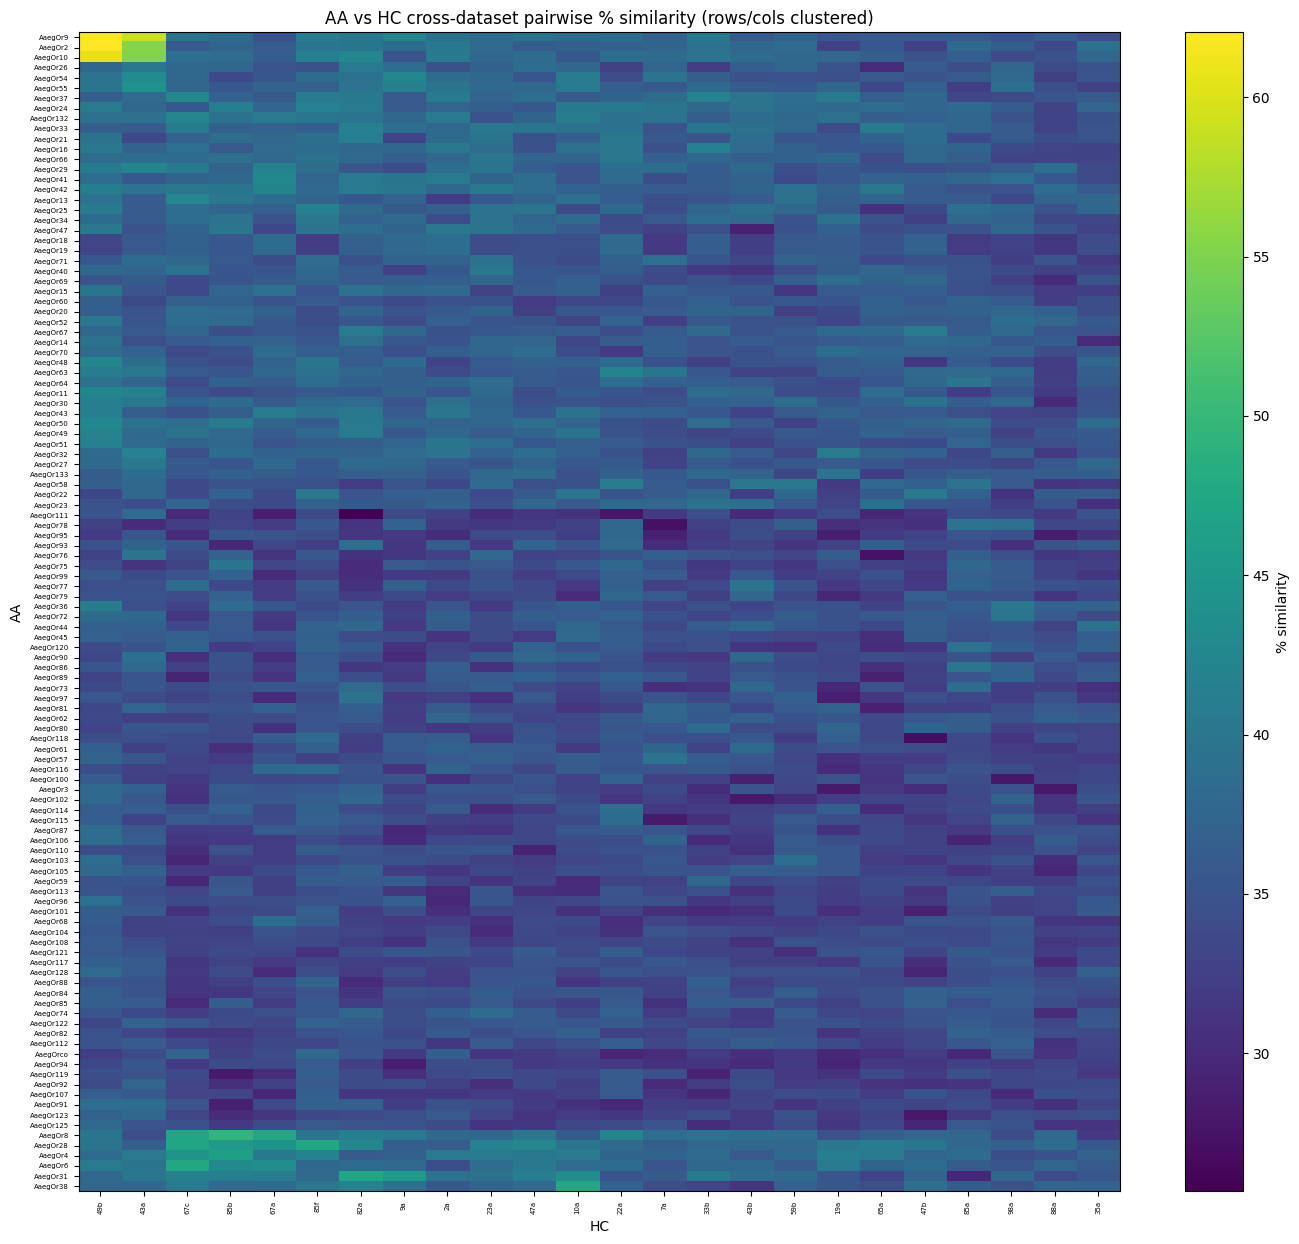

In [9]:
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import pdist


def cross_compare(name_a, name_b):
    """Cross-dataset BLOSUM62 % similarity: every receptor in A vs every receptor in B.
    Writes ../results/{A}_vs_{B}_similarity_matrix.csv + ..._heatmap.png, returns the DataFrame."""
    names_a, seqs_a = data[name_a]["names"], data[name_a]["seqs"]
    names_b, seqs_b = data[name_b]["names"], data[name_b]["seqs"]
    cross = np.zeros((len(seqs_a), len(seqs_b)))
    for i, sa in enumerate(seqs_a):
        for j, sb in enumerate(seqs_b):
            aln = aligner.align(sa, sb)[0]
            _, sim = score_alignment(aln, blosum62)
            cross[i, j] = sim

    df = pd.DataFrame(cross, index=names_a, columns=names_b)
    df.round(1).to_csv(f"../results/{name_a}_vs_{name_b}_similarity_matrix.csv")

    print(f"=== {name_a} vs {name_b}: {cross.size} cross pairs ===")
    print(f"  % similarity: min={cross.min():.1f} mean={cross.mean():.1f} max={cross.max():.1f}")
    best_j = cross.argmax(axis=1)
    rows = [(names_a[i], names_b[best_j[i]], cross[i, best_j[i]]) for i in range(len(names_a))]
    print(f"  Top 12 closest {name_a}->{name_b} matches:")
    for nm, bm, v in sorted(rows, key=lambda r: -r[2])[:12]:
        print(f"    {nm:>10s} -> {bm:<8s} {v:.1f}%")

    # cluster rows (A) and cols (B) independently for readable block structure
    row_order = leaves_list(linkage(pdist(cross), method="average"))
    col_order = leaves_list(linkage(pdist(cross.T), method="average"))
    M = cross[np.ix_(row_order, col_order)]
    rl = [names_a[i] for i in row_order]
    cl = [names_b[j] for j in col_order]
    fig, ax = plt.subplots(figsize=(14, max(6, 0.11 * len(rl))))
    im = ax.imshow(M, cmap="viridis", aspect="auto", vmin=cross.min(), vmax=cross.max())
    ax.set_xticks(range(len(cl))); ax.set_xticklabels(cl, rotation=90, fontsize=5)
    ax.set_yticks(range(len(rl))); ax.set_yticklabels(rl, fontsize=5)
    ax.set_xlabel(name_b); ax.set_ylabel(name_a)
    ax.set_title(f"{name_a} vs {name_b} cross-dataset pairwise % similarity (rows/cols clustered)")
    fig.colorbar(im, ax=ax, label="% similarity")
    plt.tight_layout()
    plt.savefig(f"../results/{name_a}_vs_{name_b}_similarity_heatmap.png", dpi=150)
    plt.show()
    return df


aa_vs_cc = cross_compare("AA", "CC")
aa_vs_hc = cross_compare("AA", "HC")

### AA in context: within- vs cross-dataset similarity

Quick comparison of the AA self-similarity distribution against AA-vs-CC and AA-vs-HC, to
see whether the *Aedes* receptors look closer to *Anopheles* (CC) or *Drosophila* (HC).

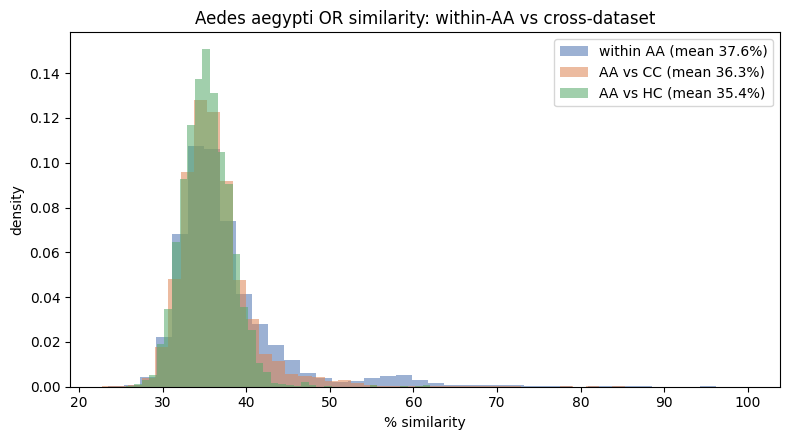

within-AA  mean=37.6%  median=35.9%
AA vs CC   mean=36.3%  median=35.6%
AA vs HC   mean=35.4%  median=35.2%


In [10]:
n_aa = len(data["AA"]["seqs"])
within_aa = data["AA"]["psim"][np.triu_indices(n_aa, k=1)]
xcc = aa_vs_cc.values.ravel()
xhc = aa_vs_hc.values.ravel()

fig, ax = plt.subplots(figsize=(8, 4.5))
for vals, lab, c in [(within_aa, "within AA", "#4c72b0"),
                     (xcc, "AA vs CC", "#dd8452"),
                     (xhc, "AA vs HC", "#55a868")]:
    ax.hist(vals, bins=40, alpha=0.55, density=True, label=f"{lab} (mean {vals.mean():.1f}%)", color=c)
ax.set(xlabel="% similarity", ylabel="density",
       title="Aedes aegypti OR similarity: within-AA vs cross-dataset")
ax.legend()
plt.tight_layout()
plt.savefig("../results/AA_similarity_distributions.png", dpi=150)
plt.show()

print(f"within-AA  mean={within_aa.mean():.1f}%  median={np.median(within_aa):.1f}%")
print(f"AA vs CC   mean={xcc.mean():.1f}%  median={np.median(xcc):.1f}%")
print(f"AA vs HC   mean={xhc.mean():.1f}%  median={np.median(xhc):.1f}%")

## 6. Cross-species summary (shareable)

A one-glance overview across all three receptor families — *Drosophila* (**HC**),
*Anopheles* (**CC**), and *Aedes aegypti* (**AA**). This section writes three small,
self-contained artifacts you can drop into a slide or email:

- `species_summary.csv` — per-species table (n receptors, length, within-family similarity)
- `species_similarity_3x3.csv` — mean % similarity matrix (within- on the diagonal, cross- off)
- `species_summary_overview.png` — the figure below (species matrix + distribution boxplots)
- `AA_top_orthologs.csv` — each AA receptor's closest CC and HC match

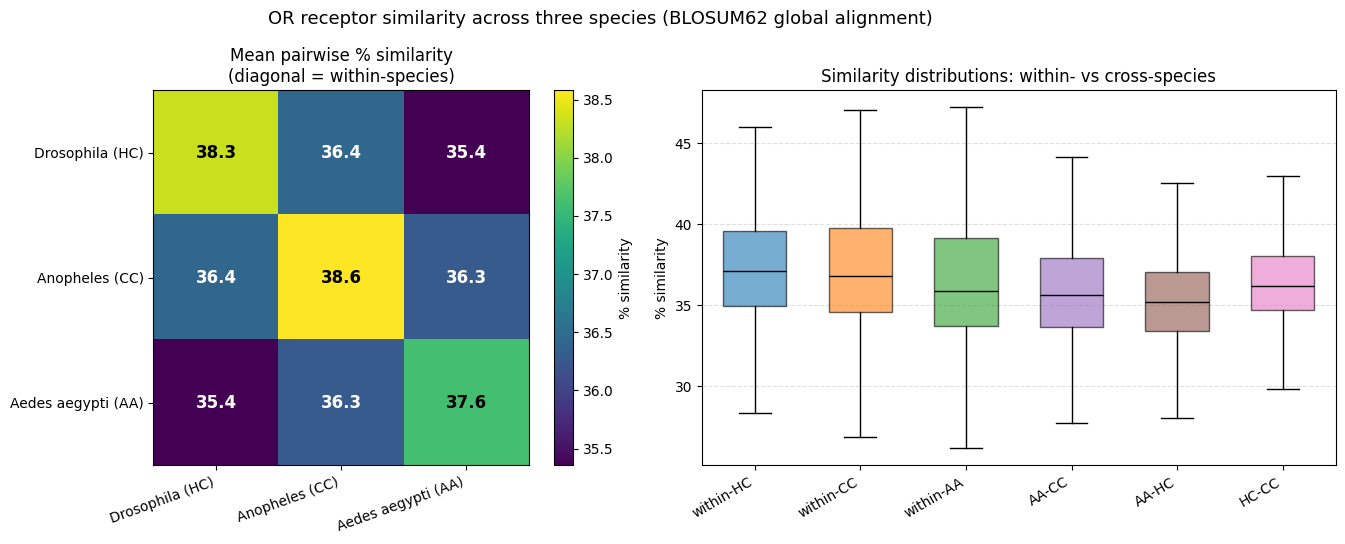

PER-SPECIES SUMMARY
dataset            species  n_receptors  seq_len_mean  within_pct_identity  within_pct_similarity
     HC    Drosophila (HC)           24         396.0                 20.5                   38.3
     CC     Anopheles (CC)           50         396.0                 21.2                   38.6
     AA Aedes aegypti (AA)          114         402.0                 20.1                   37.6

SPECIES-LEVEL MEAN % SIMILARITY (within on diagonal)
                    Drosophila (HC)  Anopheles (CC)  Aedes aegypti (AA)
Drosophila (HC)                38.3            36.4                35.4
Anopheles (CC)                 36.4            38.6                36.3
Aedes aegypti (AA)             35.4            36.3                37.6

HEADLINES:
  - 13/114 Aedes receptors have a >=60% Anopheles (CC) ortholog; best is AaegOr10 -> AgOr10 (85.4%).
  - Aedes sits closer to Anopheles (AA-CC mean 36.3%) than to Drosophila (AA-HC mean 35.4%).
  - Strongest AA<->HC match is only 62.0

In [11]:
SPECIES = {"HC": "Drosophila (HC)", "CC": "Anopheles (CC)", "AA": "Aedes aegypti (AA)"}
ORDER = ["HC", "CC", "AA"]

def within_offdiag(name):
    M = data[name]["psim"]; n = len(M)
    return M[np.triu_indices(n, k=1)]

# all three cross matrices (reuse what we already computed; load HC-vs-CC from its CSV)
cross = {
    ("AA", "CC"): aa_vs_cc.values,
    ("AA", "HC"): aa_vs_hc.values,
    ("HC", "CC"): pd.read_csv("../results/HC_vs_CC_similarity_matrix.csv", index_col=0).values,
}
def cross_vals(a, b):
    return cross[(a, b)].ravel() if (a, b) in cross else cross[(b, a)].ravel()

# ---- per-species summary table ----
rows = []
for name in ORDER:
    pid, psim = data[name]["pid"], data[name]["psim"]
    n = len(pid); iu = np.triu_indices(n, k=1)
    seqlen = np.array([len(s) for s in data[name]["seqs"]])
    rows.append({
        "dataset": name, "species": SPECIES[name], "n_receptors": n,
        "seq_len_mean": round(seqlen.mean(), 0),
        "within_pct_identity": round(pid[iu].mean(), 1),
        "within_pct_similarity": round(psim[iu].mean(), 1),
    })
summary_df = pd.DataFrame(rows)
summary_df.to_csv("../results/species_summary.csv", index=False)

# ---- 3x3 species-level mean similarity matrix ----
S = np.array([[within_offdiag(a).mean() if a == b else cross_vals(a, b).mean()
               for b in ORDER] for a in ORDER])
S_df = pd.DataFrame(np.round(S, 1), index=[SPECIES[o] for o in ORDER],
                    columns=[SPECIES[o] for o in ORDER])
S_df.to_csv("../results/species_similarity_3x3.csv")

# ---- AA closest ortholog per receptor (CC and HC) ----
cc_names, hc_names = data["CC"]["names"], data["HC"]["names"]
acc, ahc = aa_vs_cc.values, aa_vs_hc.values
ortho = pd.DataFrame({
    "AA_receptor": data["AA"]["names"],
    "status": pd.read_csv(DATASETS["AA"]["csv"])["status"].values,
    "best_CC": [cc_names[j] for j in acc.argmax(1)],
    "best_CC_pct": np.round(acc.max(1), 1),
    "best_HC": [hc_names[j] for j in ahc.argmax(1)],
    "best_HC_pct": np.round(ahc.max(1), 1),
}).sort_values("best_CC_pct", ascending=False)
ortho.to_csv("../results/AA_top_orthologs.csv", index=False)

# ---- shareable overview figure ----
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

ax = axes[0]
im = ax.imshow(S, cmap="viridis")
ax.set_xticks(range(3)); ax.set_xticklabels([SPECIES[o] for o in ORDER], rotation=20, ha="right")
ax.set_yticks(range(3)); ax.set_yticklabels([SPECIES[o] for o in ORDER])
thresh = S.min() + 0.6 * (S.max() - S.min())
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{S[i, j]:.1f}", ha="center", va="center", fontsize=12,
                fontweight="bold", color="white" if S[i, j] < thresh else "black")
ax.set_title("Mean pairwise % similarity\n(diagonal = within-species)")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="% similarity")

ax = axes[1]
groups = [("within-HC", within_offdiag("HC"), "#1f77b4"),
          ("within-CC", within_offdiag("CC"), "#ff7f0e"),
          ("within-AA", within_offdiag("AA"), "#2ca02c"),
          ("AA-CC", cross_vals("AA", "CC"), "#9467bd"),
          ("AA-HC", cross_vals("AA", "HC"), "#8c564b"),
          ("HC-CC", cross_vals("HC", "CC"), "#e377c2")]
bp = ax.boxplot([g[1] for g in groups], showfliers=False, patch_artist=True, widths=0.6)
for patch, g in zip(bp["boxes"], groups):
    patch.set_facecolor(g[2]); patch.set_alpha(0.6)
for med in bp["medians"]:
    med.set_color("black")
ax.set_xticks(range(1, len(groups) + 1))
ax.set_xticklabels([g[0] for g in groups], rotation=30, ha="right")
ax.set_ylabel("% similarity")
ax.set_title("Similarity distributions: within- vs cross-species")
ax.grid(axis="y", ls="--", alpha=0.4)

fig.suptitle("OR receptor similarity across three species (BLOSUM62 global alignment)", fontsize=13)
fig.tight_layout()
fig.savefig("../results/species_summary_overview.png", dpi=150)
plt.show()

# ---- printed headline takeaways ----
print("PER-SPECIES SUMMARY")
print(summary_df.to_string(index=False))
print("\nSPECIES-LEVEL MEAN % SIMILARITY (within on diagonal)")
print(S_df.to_string())
n_strong = int((ortho["best_CC_pct"] >= 60).sum())
print(f"\nHEADLINES:")
print(f"  - {n_strong}/{len(ortho)} Aedes receptors have a >=60% Anopheles (CC) ortholog; "
      f"best is {ortho.iloc[0].AA_receptor} -> {ortho.iloc[0].best_CC} ({ortho.iloc[0].best_CC_pct}%).")
print(f"  - Aedes sits closer to Anopheles (AA-CC mean {cross_vals('AA','CC').mean():.1f}%) "
      f"than to Drosophila (AA-HC mean {cross_vals('AA','HC').mean():.1f}%).")
print(f"  - Strongest AA<->HC match is only {ahc.max():.1f}% -> no close Drosophila orthologs.")
print("\nTop 5 Aedes orthologs:")
print(ortho.head(5).to_string(index=False))